In [2]:
import pandas as pd

df = pd.read_csv("/content/student_performance.csv")

In [3]:
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
193643,193644,23.2,88.0,9.3,100.0,A
193644,193645,11.6,82.1,4.0,68.1,C
193645,193646,6.5,84.0,5.1,62.5,C
193646,193647,10.4,86.6,6.0,67.0,C


In [4]:
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [5]:
df.shape

(193648, 6)

In [6]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,193648.000000,193648.000000,193648.000000,193647.000000,193647.000000
mean,96824.500000,15.047698,84.712199,5.977185,84.310556
std,55901.506801,6.897067,9.431660,1.954113,15.441965
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,48412.750000,10.300000,78.300000,4.600000,73.900000
50%,96824.500000,15.000000,85.000000,6.000000,87.500000
75%,145236.250000,19.700000,91.800000,7.300000,100.000000
max,193648.000000,40.000000,100.000000,10.000000,100.000000


In [7]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,1
total_score,1
grade,1


In [8]:
df

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
...,...,...,...,...,...,...
193643,193644,23.2,88.0,9.3,100.0,A
193644,193645,11.6,82.1,4.0,68.1,C
193645,193646,6.5,84.0,5.1,62.5,C
193646,193647,10.4,86.6,6.0,67.0,C


In [9]:
df_sample = df.sample(n = 5000 , random_state = 7)

In [10]:
df_sample.shape[0]

5000

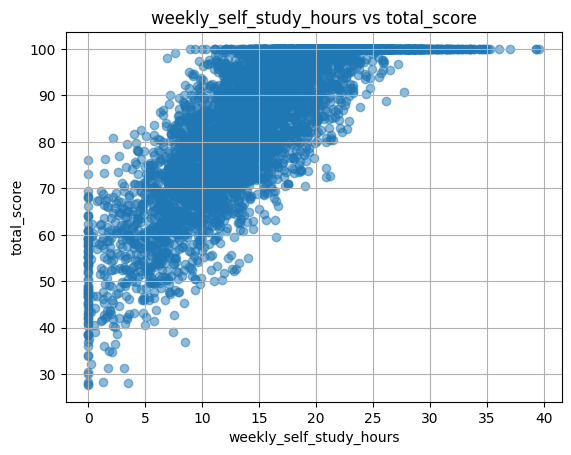

In [11]:
import matplotlib.pyplot as plt
plt.scatter(df_sample["weekly_self_study_hours"], df_sample["total_score"], alpha = 0.5)
plt.title("weekly_self_study_hours vs total_score")
plt.xlabel("weekly_self_study_hours")
plt.ylabel("total_score")
plt.grid(True)
plt.show()

In [12]:
X = df_sample[["weekly_self_study_hours"]]
Y = df_sample[["total_score"]]

In [13]:
X

,weekly_self_study_hours
157122,12.9
35975,0.0
149560,17.0
55618,11.0
188799,10.3
...,...
170817,12.8
160366,16.9
118454,13.7
47890,12.4


In [14]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [15]:
X_test

,weekly_self_study_hours
3534,29.7
40877,26.4
126323,19.6
171031,15.7
157342,12.6
...,...
62078,6.0
114717,13.4
143424,26.0
144967,24.0


In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, Y_train)

LinearRegression()

In [17]:
slope = model.coef_[0]
intercept = model.intercept_

In [18]:
slope

array([1.83524925])

In [19]:
intercept

array([56.70477769])

In [20]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual Score": Y_test[:10].values.flatten(), "Predicted Score" : y_pred[:10].flatten()})

In [ ]:
comparison

In [21]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.6337611208843715


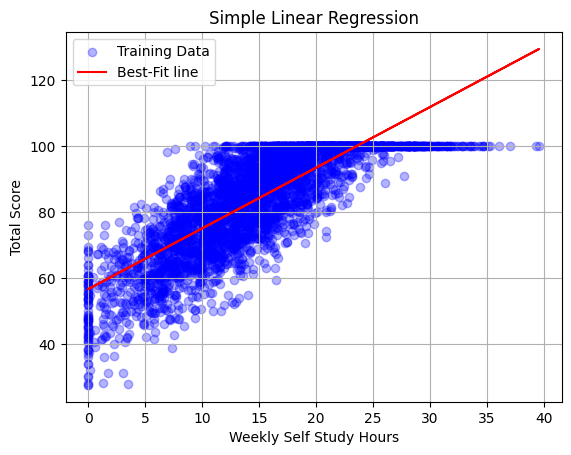

In [22]:
plt.scatter(X_train , Y_train , alpha = 0.3 , color = "blue" , label = "Training Data")
plt.plot(X_train , model.predict(X_train) , color = "red" , label = "Best-Fit line")

plt.title("Simple Linear Regression")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Total Score")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 7.195566375894617


In [24]:
# Step 1 - Import all the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [25]:
# Step 2 = Loading the Data

df = pd.read_csv("/content/student_performance.csv")

In [ ]:
# Step 3 - Taking a sample of 5000 students

df_sample = df.sample(n = 5000 , random_state = 7)

In [26]:
df_sample

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
157122,157123,12.9,76.9,6.6,74.1,B
35975,35976,0.0,92.1,5.1,59.2,C
149560,149561,17.0,82.5,4.6,100.0,A
55618,55619,11.0,69.0,4.9,74.4,B
188799,188800,10.3,100.0,5.9,74.4,B
...,...,...,...,...,...,...
170817,170818,12.8,81.0,9.4,69.8,C
160366,160367,16.9,76.7,5.2,89.5,A
118454,118455,13.7,82.4,7.0,82.8,B
47890,47891,12.4,90.7,6.3,79.8,B


In [27]:
# Step 4 - Use all 3 Features

features = ["weekly_self_study_hours", "attendance_percentage", "class_participation"]

x = df_sample[features]

In [28]:
x

,weekly_self_study_hours,attendance_percentage,class_participation
157122,12.9,76.9,6.6
35975,0.0,92.1,5.1
149560,17.0,82.5,4.6
55618,11.0,69.0,4.9
188799,10.3,100.0,5.9
...,...,...,...
170817,12.8,81.0,9.4
160366,16.9,76.7,5.2
118454,13.7,82.4,7.0
47890,12.4,90.7,6.3


In [29]:
y = df_sample["total_score"]
y

,total_score
157122,74.1
35975,59.2
149560,100.0
55618,74.4
188799,74.4
...,...
170817,69.8
160366,89.5
118454,82.8
47890,79.8


In [30]:
# Step 5 - Splitting the Data Training 80% - Testing 20%

x_train , x_test , y_train , y_test = train_test_split(x, y , test_size = 0.2 , random_state = 42)

In [31]:
# Step 6 - Training the Model

model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [32]:
coefficients = model.coef_
intercept = model.intercept_

In [33]:
x

,weekly_self_study_hours,attendance_percentage,class_participation
157122,12.9,76.9,6.6
35975,0.0,92.1,5.1
149560,17.0,82.5,4.6
55618,11.0,69.0,4.9
188799,10.3,100.0,5.9
...,...,...,...
170817,12.8,81.0,9.4
160366,16.9,76.7,5.2
118454,13.7,82.4,7.0
47890,12.4,90.7,6.3


In [34]:
coefficients

array([ 1.83571654, -0.01140591,  0.17621668])

In [35]:
intercept

np.float64(56.61237808326909)

In [36]:
# Step 7 - Predict and Test the model

y_pred = model.predict(x_test)

compare = pd.DataFrame({"Actual Score": y_test[:10].values.flatten(), "Predicted Score" : y_pred[:10].flatten()})

In [37]:
compare

,Actual Score,Predicted Score
0,100.0,111.539633
1,100.0,104.665353
2,99.0,92.354020
3,89.8,85.281348
4,79.6,80.300516
5,81.3,84.225603
6,66.1,66.837560
7,92.1,98.941494
8,92.3,80.956891
9,100.0,93.752852


In [38]:
comparison

,Actual Score,Predicted Score
0,100.0,111.211680
1,100.0,105.155358
2,99.0,92.675663
3,89.8,85.518191
4,79.6,79.828918
5,81.3,84.600566
6,66.1,67.165698
7,92.1,99.282560
8,92.3,81.480643
9,100.0,93.776813


In [39]:
r2 = r2_score(y_test , y_pred)

In [40]:
r2

0.6343255378255024

In [41]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 7.182368656265949
